**Import Library**

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Estimators
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, roc_curve)


**Load DataSet**

In [56]:
df=pd.read_csv("/content/UK Train Rides new.csv")
df

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648,1304623d-b8b7-4999-8e9c,2024-04-30,18:42:58,Online,Credit Card,NaN,Standard,Off-Peak,4,Manchester Piccadilly,Liverpool Lime Street,2024-04-30,20:00:00,20:30:00,20:30:00,On Time,No
31649,7da22246-f480-417c-bc2f,2024-04-30,18:46:10,Online,Contactless,NaN,Standard,Off-Peak,10,London Euston,Birmingham New Street,2024-04-30,20:15:00,21:35:00,21:35:00,On Time,No
31650,add9debf-46c1-4c75-b52d,2024-04-30,18:56:41,Station,Credit Card,NaN,Standard,Off-Peak,4,Manchester Piccadilly,Liverpool Lime Street,2024-04-30,20:15:00,20:45:00,20:45:00,On Time,No
31651,b92b047c-21fd-4859-966a,2024-04-30,19:51:47,Station,Credit Card,NaN,Standard,Off-Peak,10,London Euston,Birmingham New Street,2024-04-30,21:15:00,22:35:00,22:35:00,On Time,No


In [57]:
df.shape

(31653, 17)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  31653 non-null  object
 15  Journey Status       31653 non-null  object
 16  Refu

**EDA**

In [59]:
df.isnull().sum()

,0
Transaction ID,0
Date of Purchase,0
Time of Purchase,0
Purchase Type,0
Payment Method,0
Railcard,20918
Ticket Class,0
Ticket Type,0
Price,0
Departure Station,0


In [60]:
df['Railcard']=df['Railcard'].fillna("Disabled")

In [61]:
df.isnull().sum()

,0
Transaction ID,0
Date of Purchase,0
Time of Purchase,0
Purchase Type,0
Payment Method,0
Railcard,0
Ticket Class,0
Ticket Type,0
Price,0
Departure Station,0


In [62]:
df.describe()

,Price
count,31653.000000
mean,23.439200
std,29.997628
min,1.000000
25%,5.000000
50%,11.000000
75%,35.000000
max,267.000000


In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df['Journey Status'].value_counts()

,count
Journey Status,
On Time,27481
Delayed,2292
Cancelled,1880


**Feature Engineering**

In [65]:
df['Departure hour']= pd.to_datetime( df['Departure Time'])
df['Departure hour']

/tmp/ipykernel_391/2460467318.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure hour']= pd.to_datetime( df['Departure Time'])


,Departure hour
0,2026-09-20 11:00:00
1,2026-09-20 09:45:00
2,2026-09-20 18:15:00
3,2026-09-20 21:30:00
4,2026-09-20 16:45:00
...,...
31648,2026-09-20 20:00:00
31649,2026-09-20 20:15:00
31650,2026-09-20 20:15:00
31651,2026-09-20 21:15:00


In [66]:
df['Arrival hour']= pd.to_datetime( df['Arrival Time'])
df['Arrival hour']

/tmp/ipykernel_391/3929408515.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival hour']= pd.to_datetime( df['Arrival Time'])


,Arrival hour
0,2026-09-20 13:30:00
1,2026-09-20 11:35:00
2,2026-09-20 18:45:00
3,2026-09-20 22:30:00
4,2026-09-20 19:00:00
...,...
31648,2026-09-20 20:30:00
31649,2026-09-20 21:35:00
31650,2026-09-20 20:45:00
31651,2026-09-20 22:35:00


In [67]:
df['Journey Duration']=df['Arrival hour'] - df['Departure hour']
df['Journey Duration']

,Journey Duration
0,0 days 02:30:00
1,0 days 01:50:00
2,0 days 00:30:00
3,0 days 01:00:00
4,0 days 02:15:00
...,...
31648,0 days 00:30:00
31649,0 days 01:20:00
31650,0 days 00:30:00
31651,0 days 01:20:00


In [68]:
df['Actual Arrival hour'] = pd.to_datetime(df['Actual Arrival Time'],errors='coerce')
df['Actual Arrival hour']

/tmp/ipykernel_391/92707634.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Actual Arrival hour'] = pd.to_datetime(df['Actual Arrival Time'],errors='coerce')


,Actual Arrival hour
0,2026-09-20 13:30:00
1,2026-09-20 11:40:00
2,2026-09-20 18:45:00
3,2026-09-20 22:30:00
4,2026-09-20 19:00:00
...,...
31648,2026-09-20 20:30:00
31649,2026-09-20 21:35:00
31650,2026-09-20 20:45:00
31651,2026-09-20 22:35:00


In [69]:
df['delay time'] = df['Actual Arrival hour'] - df['Arrival hour']
df['delay time']

,delay time
0,0 days 00:00:00
1,0 days 00:05:00
2,0 days 00:00:00
3,0 days 00:00:00
4,0 days 00:00:00
...,...
31648,0 days 00:00:00
31649,0 days 00:00:00
31650,0 days 00:00:00
31651,0 days 00:00:00


In [70]:
df['is_Delay']=(df['delay time'] > pd.Timedelta(0) ).astype(int)
df['is_Delay']

,is_Delay
0,0
1,1
2,0
3,0
4,0
...,...
31648,0
31649,0
31650,0
31651,0


In [71]:
df['Date of Journey'] = pd.to_datetime( df['Date of Journey'])
df['day of Journey'] = df['Date of Journey'].dt.day
df['day of Journey']

,day of Journey
0,1
1,1
2,2
3,1
4,1
...,...
31648,30
31649,30
31650,30
31651,30


In [72]:
df['month of Journey'] = df['Date of Journey'].dt.month
df['month of Journey']

,month of Journey
0,1
1,1
2,1
3,1
4,1
...,...
31648,4
31649,4
31650,4
31651,4


In [73]:
df['Day of Journey'] = df['Date of Journey'].dt.day_of_week
df['Day of Journey']

,Day of Journey
0,0
1,0
2,1
3,0
4,0
...,...
31648,1
31649,1
31650,1
31651,1


**delete columns**

In [74]:
df_clean=df.drop(columns=['Transaction ID','Refund Request'])
df_clean

,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,...,Journey Status,Departure hour,Arrival hour,Journey Duration,Actual Arrival hour,delay time,is_Delay,day of Journey,month of Journey,Day of Journey
0,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,...,On Time,2026-09-20 11:00:00,2026-09-20 13:30:00,0 days 02:30:00,2026-09-20 13:30:00,0 days 00:00:00,0,1,1,0
1,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,...,Delayed,2026-09-20 09:45:00,2026-09-20 11:35:00,0 days 01:50:00,2026-09-20 11:40:00,0 days 00:05:00,1,1,1,0
2,2023-12-19,19:51:27,Online,Credit Card,Disabled,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,...,On Time,2026-09-20 18:15:00,2026-09-20 18:45:00,0 days 00:30:00,2026-09-20 18:45:00,0 days 00:00:00,0,2,1,1
3,2023-12-20,23:00:36,Station,Credit Card,Disabled,Standard,Advance,13,London Paddington,Reading,...,On Time,2026-09-20 21:30:00,2026-09-20 22:30:00,0 days 01:00:00,2026-09-20 22:30:00,0 days 00:00:00,0,1,1,0
4,2023-12-27,18:22:56,Online,Contactless,Disabled,Standard,Advance,76,Liverpool Lime Street,London Euston,...,On Time,2026-09-20 16:45:00,2026-09-20 19:00:00,0 days 02:15:00,2026-09-20 19:00:00,0 days 00:00:00,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648,2024-04-30,18:42:58,Online,Credit Card,Disabled,Standard,Off-Peak,4,Manchester Piccadilly,Liverpool Lime Street,...,On Time,2026-09-20 20:00:00,2026-09-20 20:30:00,0 days 00:30:00,2026-09-20 20:30:00,0 days 00:00:00,0,30,4,1
31649,2024-04-30,18:46:10,Online,Contactless,Disabled,Standard,Off-Peak,10,London Euston,Birmingham New Street,...,On Time,2026-09-20 20:15:00,2026-09-20 21:35:00,0 days 01:20:00,2026-09-20 21:35:00,0 days 00:00:00,0,30,4,1
31650,2024-04-30,18:56:41,Station,Credit Card,Disabled,Standard,Off-Peak,4,Manchester Piccadilly,Liverpool Lime Street,...,On Time,2026-09-20 20:15:00,2026-09-20 20:45:00,0 days 00:30:00,2026-09-20 20:45:00,0 days 00:00:00,0,30,4,1
31651,2024-04-30,19:51:47,Station,Credit Card,Disabled,Standard,Off-Peak,10,London Euston,Birmingham New Street,...,On Time,2026-09-20 21:15:00,2026-09-20 22:35:00,0 days 01:20:00,2026-09-20 22:35:00,0 days 00:00:00,0,30,4,1


**Encoding**

In [75]:
X = df_clean.drop(columns=['delay time'])
y = df_clean['delay time']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')


Train shape: (25322, 23), Test shape: (6331, 23)


In [76]:
categorical=[
    'Journey Status',
    'Arrival Destination',
    'Departure Station',
    'Ticket Class',
    'Railcard',
    'Payment Method',
    'Purchase Type',
    'Ticket Type'
]

In [77]:
# One-hot encoding
X_train_encoded = pd.get_dummies(X_train, columns=categorical, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical, drop_first=True)

In [78]:
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
X_train_encoded.head(5)

,Date of Purchase,Time of Purchase,Price,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Departure hour,Arrival hour,Journey Duration,...,Departure Station_Reading,Departure Station_York,Ticket Class_Standard,Railcard_Disabled,Railcard_Senior,Payment Method_Credit Card,Payment Method_Debit Card,Purchase Type_Station,Ticket Type_Anytime,Ticket Type_Off-Peak
3287,2024-01-13,20:12:46,38,2024-01-14,18:30:00,20:20:00,20:20:00,2026-09-20 18:30:00,2026-09-20 20:20:00,0 days 01:50:00,...,False,False,False,False,False,False,False,True,False,False
24180,2024-04-02,17:37:25,4,2024-04-03,16:00:00,17:20:00,18:19:00,2026-09-20 16:00:00,2026-09-20 17:20:00,0 days 01:20:00,...,False,False,True,False,False,True,False,True,False,False
10235,2024-02-05,05:07:10,84,2024-02-06,03:30:00,05:20:00,06:10:00,2026-09-20 03:30:00,2026-09-20 05:20:00,0 days 01:50:00,...,False,False,True,True,False,True,False,True,False,False
13988,2024-02-15,18:32:56,10,2024-02-15,20:00:00,21:20:00,21:20:00,2026-09-20 20:00:00,2026-09-20 21:20:00,0 days 01:20:00,...,False,False,True,True,False,True,False,False,False,True
30747,2024-04-27,05:19:24,12,2024-04-27,06:45:00,08:05:00,08:05:00,2026-09-20 06:45:00,2026-09-20 08:05:00,0 days 01:20:00,...,False,False,True,True,False,False,False,False,False,True


In [79]:
print(X_train_encoded.dtypes)

Date of Purchase                      object
Time of Purchase                      object
Price                                  int64
Date of Journey               datetime64[ns]
Departure Time                        object
                                   ...      
Payment Method_Credit Card              bool
Payment Method_Debit Card               bool
Purchase Type_Station                   bool
Ticket Type_Anytime                     bool
Ticket Type_Off-Peak                    bool
Length: 67, dtype: object


In [80]:
drop_cols=[
    'Date of Purchase',
    'Time of Purchase',
    'Departure Time',
    'Arrival Time',
    'Actual Arrival Time',
    'Arrival hour',
    'Departure hour',
    'Actual Arrival hour',
    'Journey Duration',
    'is_Delay'
]
X_train_encoded=X_train_encoded.drop(columns=drop_cols,errors='ignore')
X_test_encoded=X_test_encoded.drop(columns=drop_cols,errors='ignore')
print(X_train_encoded.dtypes)

Price                                                 int64
Date of Journey                              datetime64[ns]
day of Journey                                        int32
month of Journey                                      int32
Day of Journey                                        int32
Journey Status_Delayed                                 bool
Journey Status_On Time                                 bool
Arrival Destination_Bristol Temple Meads               bool
Arrival Destination_Cardiff Central                    bool
Arrival Destination_Coventry                           bool
Arrival Destination_Crewe                              bool
Arrival Destination_Didcot                             bool
Arrival Destination_Doncaster                          bool
Arrival Destination_Durham                             bool
Arrival Destination_Edinburgh                          bool
Arrival Destination_Edinburgh Waverley                 bool
Arrival Destination_Leeds               

In [81]:
X_train_encoded=X_train_encoded.astype(int)
X_test_encoded=X_test_encoded.astype(int)
print(X_train_encoded.dtypes)

Price                                        int64
Date of Journey                              int64
day of Journey                               int64
month of Journey                             int64
Day of Journey                               int64
Journey Status_Delayed                       int64
Journey Status_On Time                       int64
Arrival Destination_Bristol Temple Meads     int64
Arrival Destination_Cardiff Central          int64
Arrival Destination_Coventry                 int64
Arrival Destination_Crewe                    int64
Arrival Destination_Didcot                   int64
Arrival Destination_Doncaster                int64
Arrival Destination_Durham                   int64
Arrival Destination_Edinburgh                int64
Arrival Destination_Edinburgh Waverley       int64
Arrival Destination_Leeds                    int64
Arrival Destination_Leicester                int64
Arrival Destination_Liverpool Lime Street    int64
Arrival Destination_London Eust

In [82]:
train_mask = y_train_.notna()
test_mask = y_test.notna()

X_train_clean = X_train_encoded.loc[train_mask]
y_train_clean = y_train.loc[train_mask]

X_test_clean = X_test_encoded.loc[test_mask]
y_test_clean = y_test.loc[test_mask]

In [90]:
y_train_clean = y_train_clean.dt.total_seconds() / 60
y_test_clean = y_test_clean.dt.total_seconds() / 60

In [91]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(23798, 57)
(5975, 57)


In [92]:
models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5),
    'Support Vector Regression': SVR(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'AdaBoost': AdaBoostRegressor(
        n_estimators=200,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train_clean)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test_clean, y_pred)
    mse = mean_squared_error(y_test_clean, y_pred)
    rmse = np.sqrt(mse)  #root mean squared error
    r2 = r2_score(y_test_clean, y_pred)

    results.append({
        'Model Name': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    })

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by='R²',
    ascending=False
).reset_index(drop=True)

df_results

,Model Name,MAE,MSE,RMSE,R²
0,Random Forest,0.670398,20.237370,4.498596,0.896917
1,K-Nearest Neighbors,1.051146,33.177446,5.759987,0.831004
2,Gradient Boosting,1.314389,33.825625,5.815980,0.827703
3,Decision Tree,1.228526,35.555252,5.962823,0.818892
4,AdaBoost,1.502024,47.519772,6.893459,0.757949
5,Linear Regression,2.872438,71.161966,8.435755,0.637523
6,Support Vector Regression,1.486854,72.720271,8.527618,0.629585


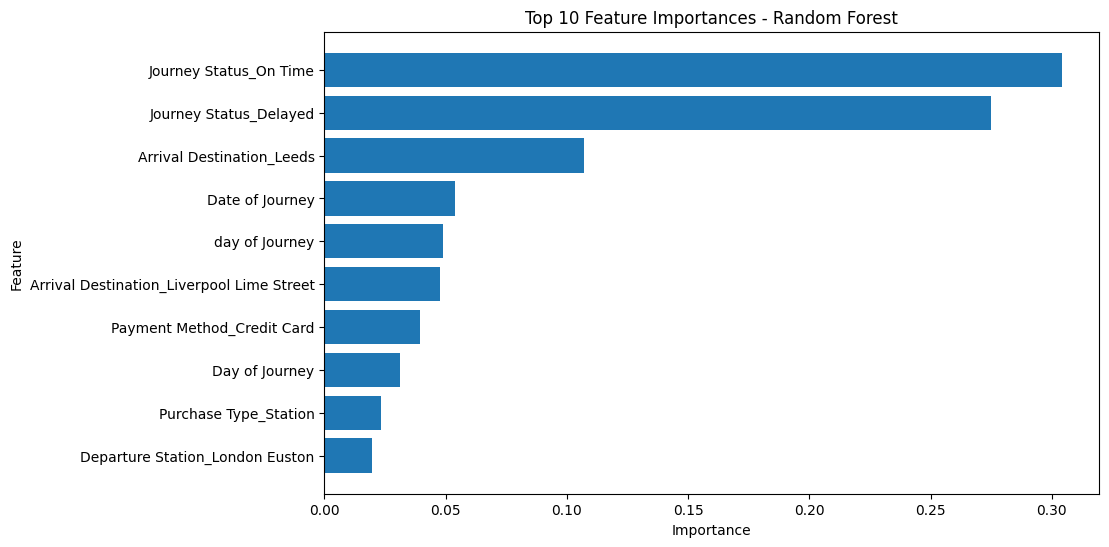

In [95]:
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({'Feature': X_train_clean.columns,'Importance': rf_model.feature_importances_})

feature_importance = feature_importance.sort_values( by='Importance', ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'],top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.show()